In [106]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation,PillowWriter
import itertools
from IPython.display import Image, display


df=pd.read_excel(r"C:\Users\DELL\Documents\AI_ML_Job_Market_Analysis.xlsx",index_col="JobID")
pd.set_option('display.width',2000)

print(df)
print(df.size)
print(df.columns)
print(df.info())
print(df.head(5))
print(df.tail(5))
print(df.duplicated)
df.drop_duplicates  
print(np.count_nonzero(df))



                          JobTitle       Company   Location ExperienceLevel  ExperienceYears EmploymentType WorkMode      Education  Salary_LPA                                             Skills PostingDate
JobID                                                                                                                                                                                                         
JOB0654                AI Engineer      TechNova    Chennai       Mid-level                4      Full-time   Remote     Bachelor's       12.11  Machine Learning, AWS, LLMs, NumPy, Spark, Sci...  2025-01-01
JOB0323             Data Scientist      TechNova       Pune          Senior                8      Full-time  On-site       Master's       21.16  SQL, Machine Learning, AWS, Statistics, NLP, P...  2025-01-03
JOB0149               Data Analyst   FutureStack   Gurugram       Mid-level                5      Part-time  On-site            NaN       11.35   Matplotlib, Generative AI,

In [107]:
#What are all the unique job titles in the dataset?

#Q7. Which 10 job titles occur most frequently?

#Q8. How many jobs are available for each experience level?

#Q9. Which employment type is most common — full-time, part-time, contract, etc.?

#Q10. What percentage of the jobs are remote?

In [108]:

print("Unique Jobs : " , df['JobTitle'].unique())
frq_jobs=df.groupby('ExperienceLevel')
pd.set_option('display.max_rows',1008)
job_L=frq_jobs['JobTitle'].value_counts().reset_index()#jobL=job at expereience level
job_L.columns = ["JobLevel", "JobTitle", "Jobavailable"]
job_avail=job_L.groupby("JobLevel")
print("Jobs available for each experience level : " ,job_avail["Jobavailable"].sum())
print("Most common employment type : " , df['EmploymentType'].value_counts().idxmax())
counts=(df["WorkMode"])=="Remote"
check=counts.value_counts(normalize=True)*100
print("Percentage of jobs which are remote : " ,check[True],"%")




Unique Jobs :  <StringArray>
['AI Engineer', 'Data Scientist', 'Data Analyst', 'MLOps Engineer', 'Deep Learning Engineer', 'Machine Learning Engineer', 'Generative AI Engineer', 'AI Research Scientist', 'Computer Vision Engineer', 'NLP Engineer']
Length: 10, dtype: str
Jobs available for each experience level :  JobLevel
Entry-level    291
Lead            70
Mid-level      407
Senior         240
Name: Jobavailable, dtype: int64
Most common employment type :  Full-time
Percentage of jobs which are remote :  30.753968253968257 %


In [109]:
#Q11. What is the average, median, minimum, and maximum salary?

#Q12. Calculate the average salary for each job title.

#Q13. Which job titles have the highest median salary?

#Q14. Divide the jobs into salary categories such as Low, Medium, and High using NumPy conditions. How many jobs fall into each category?

#Q15. Calculate the percentage of jobs requiring 0–2, 3–5, and 6+ years of experience.

In [110]:
print("Median salary (LPA): " ,df['Salary_LPA'].median())
print("Average salary (LPA): " , df['Salary_LPA'].mean())
print("Maxium salary (LPA): " , df["Salary_LPA"].max())
print("Minimum salary (LPA): " , df["Salary_LPA"].min())
salary=df.groupby('JobTitle')
print("Average salary(LPA) for each jobtitle: " , salary['Salary_LPA'].mean())
print("Highest median salary (LPA) among jobtitles : " ,salary["Salary_LPA"].median().max())
#print("Category of jobtitles based on salary : " ,np.where(df["Salary_LPA"]<=3,"Low salary",np.where(df["Salary_LPA"]<=10 ,"medium salary","high salary")))
df["salcategory"]=np.where(df["Salary_LPA"]<=3,"Low salary",np.where(df["Salary_LPA"]<=10 ,"medium salary","high salary"))
print("Count of salcategory : " ,df['salcategory'].value_counts())
df["expcategory"]=np.where(df["ExperienceYears"]<=2,"0-2 years",np.where(df["ExperienceYears"]<=5,"3-5 years","6+ years"))
print("Percentage of jobs requiring experience : ",df["expcategory"].value_counts(normalize=True)*100,"%")


Median salary (LPA):  10.855
Average salary (LPA):  11.966285425101216
Maxium salary (LPA):  29.81
Minimum salary (LPA):  2.5
Average salary(LPA) for each jobtitle:  JobTitle
AI Engineer                  12.316545
AI Research Scientist        12.762286
Computer Vision Engineer     10.699574
Data Analyst                 11.321505
Data Scientist               12.999506
Deep Learning Engineer       12.985667
Generative AI Engineer       11.022347
MLOps Engineer               11.537849
Machine Learning Engineer    12.361538
NLP Engineer                 11.663458
Name: Salary_LPA, dtype: float64
Highest median salary (LPA) among jobtitles :  12.11
Count of salcategory :  salcategory
high salary      584
medium salary    373
Low salary        51
Name: count, dtype: int64
Percentage of jobs requiring experience :  expcategory
3-5 years    40.376984
6+ years     30.753968
0-2 years    28.869048
Name: proportion, dtype: float64 %


In [111]:
#Q16. What are the 10 most frequently requested skills in AI/ML job postings?

#Q17. What percentage of job postings mention Python?

#Q18. What percentage mention SQL?

#Q19. Among jobs requiring Python, what percentage also require SQL?

#Q20. For ML Engineer jobs, which skills appear most frequently?

In [112]:
skills_count = (
    df["Skills"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts(normalize=True)*100
)

print("Top ten frequently requested skills in AI/ML job : " ,skills_count.nlargest(10))
python_percent=(
    df["Skills"].dropna().str.contains("Python").value_counts(normalize=True)*100
)
print("Python requirement : " , python_percent[True],"%")
sql_percent=(
    df["Skills"].dropna().str.contains("SQL").value_counts(normalize=True)*100
)
print("SQL requirement : " , sql_percent[True],"%")
skills = df["Skills"].dropna()

python_sql = (
    skills.str.contains("Python") &
    skills.str.contains("SQL")
)

python_sql_percent = python_sql.mean() * 100

print("Python + SQL requirement:", python_sql_percent, "%")
skills=df.groupby("JobTitle")
print("Most appeared skills in ML Engineer Job: " ,skills["Skills"].get_group("Machine Learning Engineer").str.split().explode().value_counts())


Top ten frequently requested skills in AI/ML job :  Skills
Python              7.432095
Machine Learning    7.365439
Git                 7.332111
SQL                 7.232128
PyTorch             4.732545
Generative AI       4.465922
NLP                 4.315947
Deep Learning       4.265956
LLMs                4.099317
GCP                 3.832695
Name: proportion, dtype: float64
Python requirement :  44.68937875751503 %
SQL requirement :  43.48697394789579 %
Python + SQL requirement: 19.138276553106213 %
Most appeared skills in ML Engineer Job:  Skills
Learning,        67
Machine          58
SQL,             49
Git,             45
Python,          39
Generative       31
PyTorch,         29
Docker,          28
Scikit-learn,    26
AI,              24
Power            24
AWS,             24
Deep             24
Azure,           22
Spark,           22
NumPy,           21
LLMs,            21
Statistics,      21
BI,              21
Kubernetes,      21
Computer         21
TensorFlow,      20
G

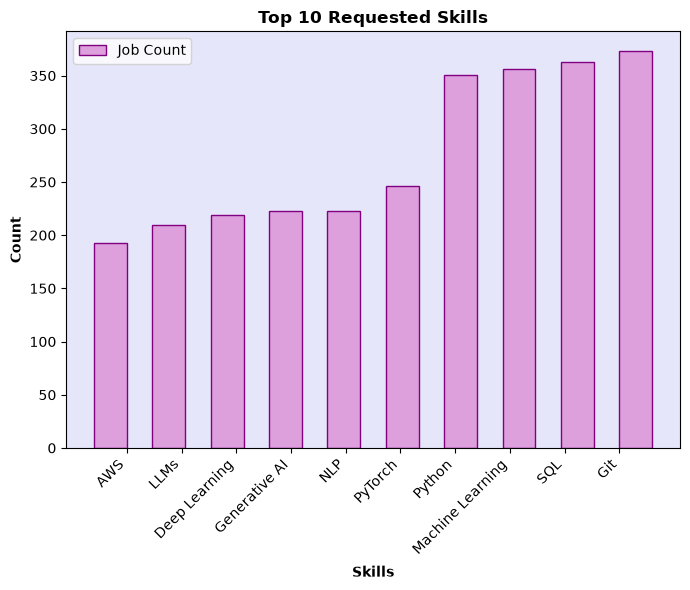

In [113]:
skillcount=df["Skills"].dropna().str.split(",").explode().value_counts().nlargest(10).reset_index()
skillcount.columns=["skills","counts"]
Skill = skillcount["skills"].iloc[::-1]
Count = skillcount["counts"].iloc[::-1]
plt.style.use('seaborn-v0_8-deep')
x = np.arange(len(Skill))

shift = np.linspace(-0.3, 0.3, len(Skill))

plt.figure(figsize=(7, 6))

plt.bar(x + shift, Count, width=0.6,
        color="plum",
        edgecolor="purple")

plt.gca().set_facecolor("lavender")

plt.xticks(x, Skill, rotation=45, ha="right")

plt.xlabel("Skills",fontweight="bold")
plt.ylabel("Count",fontweight="bold")
plt.title("Top 10 Requested Skills",fontweight="bold")

plt.legend(["Job Count"])

plt.tight_layout()
plt.show()



C:\Users\DELL\AppData\Local\Temp\ipykernel_7228\3999969840.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


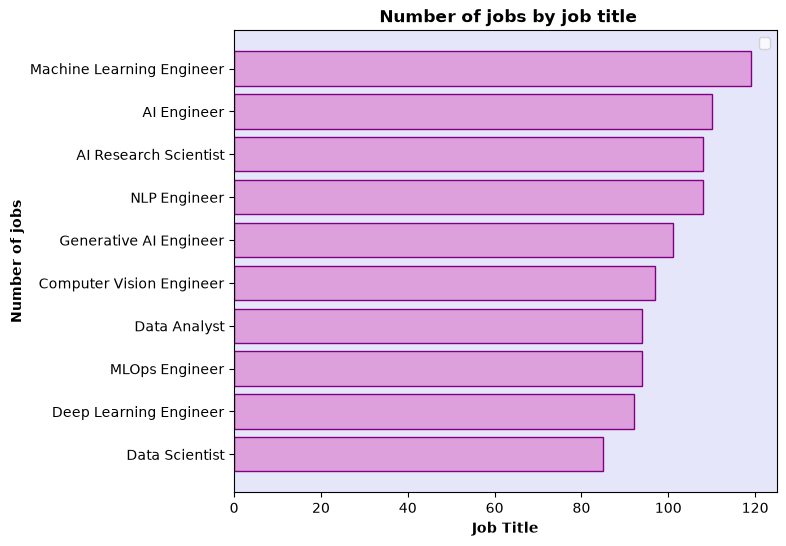

In [114]:
jobs=df["JobTitle"].value_counts().reset_index()
jobs.columns=["jobs","counts"]
Job=jobs["jobs"].iloc[::-1]
Counts=jobs["counts"].iloc[::-1]
plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(7, 6))
plt.barh(Job,Counts,color="plum",edgecolor="purple")
plt.gca().set_facecolor("lavender")
plt.xlabel("Job Title",fontweight="bold")
plt.ylabel("Number of jobs",fontweight="bold")
plt.title(" Number of jobs by job title",fontweight="bold")
plt.legend()
plt.show()

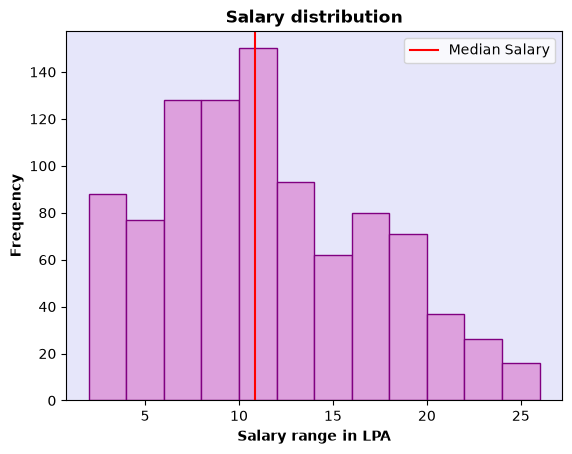

In [115]:

bins=[2,4,6,8,10,12,14,16,18,20,22,24,26]
salary=df["Salary_LPA"]
plt.style.use("seaborn-v0_8-deep")
plt.hist(salary,bins=bins,color="plum",edgecolor="purple")
plt.gca().set_facecolor("lavender")
plt.xlabel("Salary range in LPA",fontweight="bold")
plt.ylabel("Frequency",fontweight="bold")
plt.title("Salary distribution",fontweight="bold")
averagesal=df["Salary_LPA"].median()
plt.axvline(averagesal,color="red",label="Median Salary")
plt.legend()
plt.show()

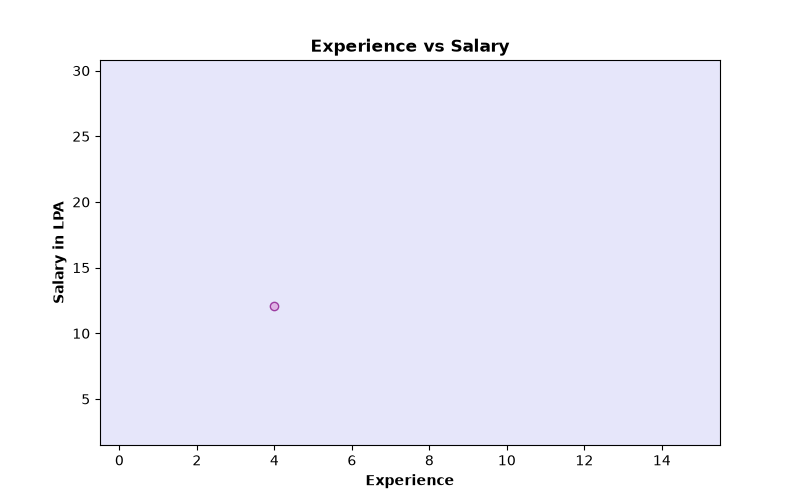

In [124]:
data = df[["ExperienceYears", "Salary_LPA"]].dropna()

x = data["ExperienceYears"].to_numpy()
y = data["Salary_LPA"].to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(
    [], [],
    color="plum",
    edgecolor="purple",
    alpha=0.7
)
plt.gca().set_facecolor("lavender")

ax.set_xlim(x.min() - 0.5, x.max() + 0.5)
ax.set_ylim(y.min() - 1, y.max() + 1)

ax.set_xlabel("Experience", fontweight="bold")
ax.set_ylabel("Salary in LPA", fontweight="bold")
ax.set_title("Experience vs Salary", fontweight="bold")

# 100 animation frames instead of thousands
frames = np.linspace(1, len(x), 100).astype(int)

def update(frame):
    scatter.set_offsets(
        np.column_stack((x[:frame], y[:frame]))
    )
    return scatter,

animation = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=80,
    repeat=True
)

animation.save(
    "experience_vs_salary.gif",
    writer=PillowWriter(fps=12)
)

plt.close(fig)

display(Image(filename="experience_vs_salary.gif"))

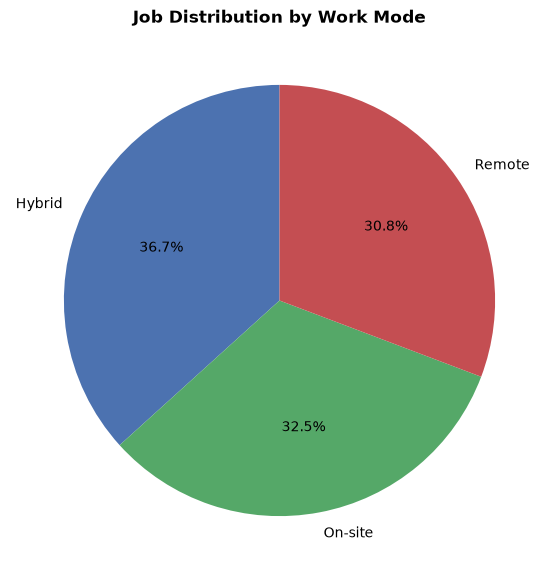

In [119]:
workmode = df["WorkMode"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    workmode.values,
    labels=workmode.index,
    autopct="%1.1f%%",
    startangle=90,
)

plt.title("Job Distribution by Work Mode", fontweight="bold")

plt.show()

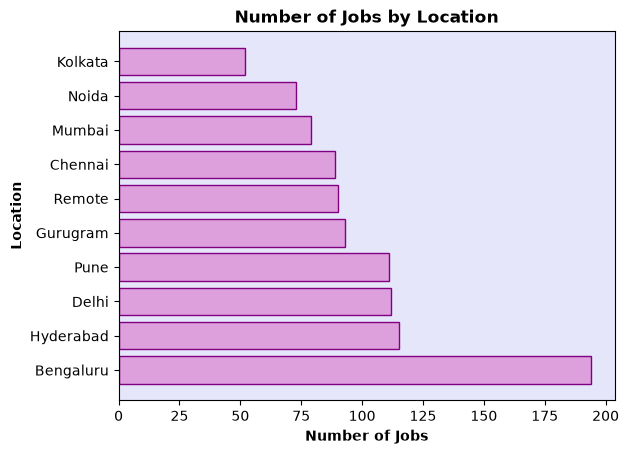

In [123]:
y = df["Location"].value_counts().reset_index()
y.columns = ["Location", "JobCount"]
plt.barh(y["Location"], y["JobCount"],color="plum",edgecolor="purple")
plt.gca().set_facecolor("lavender")
plt.xlabel("Number of Jobs",fontweight="bold")
plt.ylabel("Location",fontweight="bold")
plt.title("Number of Jobs by Location",fontweight="bold")
plt.show()